# Generate PPT Assets For Training Data Overview

这个 notebook 用来为 PPT 生成训练数据介绍所需的统计信息和图片。

建议 PPT 结构：

1. 数据来源与处理流程
   - 原始 2024 Japan 数据
   - station cache 的过滤逻辑
   - train/dev/test 和 overfit subset 的关系
2. 全量可用数据概览
   - 事件数、台站记录数、震级范围
   - KiK-net / K-NET 比例
   - surface / borehole / single_surface 比例
3. 地理覆盖和震级覆盖
   - 全量事件经纬度分布图
   - 震级直方图
4. split 结果
   - train / dev / test 的事件数与台站记录数
   - split 的地理分布图
5. overfit 子集
   - overfit selected 的震级范围和空间覆盖
   - 目前实现下 overfit 事件在 train/dev/test 中的分布
6. 波形与标签质量
   - `stalta_ratio_at_pick` 分布
   - 每事件台站数分布
   - PGA 分布（如果需要）
7. 需要说明的 caveat
   - 当前 overfit 不是 `train == dev`，而是 selected events 与 split 的交集
   - 所以 overfit selected 会出现在 train/dev/test 三个 split 中

In [1]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['savefig.dpi'] = 160

In [2]:
# 如果你的本地目录是 /tmp/japan_build/test3，把这个变量改掉即可
BASE_DIR = Path('/tmp/japan_build_test3')
OUT_DIR = Path('/home/zhangb/work/people/zhangbei/team_claude/team_pytorch/ppt_figures/data_overview_2024_overfit')
OUT_DIR.mkdir(parents=True, exist_ok=True)

station_cache_path = BASE_DIR / 'station_cache_d9a7d4d6.csv'
split_events_path = BASE_DIR / 'split_events.csv'
split_stations_path = BASE_DIR / 'split_stations.csv'

print('BASE_DIR =', BASE_DIR)
print('OUT_DIR  =', OUT_DIR)
print('station_cache exists =', station_cache_path.exists())
print('split_events exists  =', split_events_path.exists())
print('split_stations exists=', split_stations_path.exists())

BASE_DIR = /tmp/japan_build_test3
OUT_DIR  = /home/zhangb/work/people/zhangbei/team_claude/team_pytorch/ppt_figures/data_overview_2024_overfit
station_cache exists = True
split_events exists  = True
split_stations exists= True


In [5]:
station_cache = pd.read_csv(station_cache_path)
split_events = pd.read_csv(split_events_path)
split_stations = pd.read_csv(split_stations_path)

for df in [station_cache, split_events, split_stations]:
    if 'EVENT' in df.columns:
        df['EVENT'] = df['EVENT'].astype(str)

full_events = station_cache.drop_duplicates('EVENT').copy()
full_event_station_counts = station_cache.groupby('EVENT').size().rename('n_station_rows').reset_index()
full_events = full_events.merge(full_event_station_counts, on='EVENT', how='left')

overfit_events = split_events[split_events['is_overfit_selected']].copy()
overfit_stations = split_stations[split_stations['is_overfit_selected']].copy()

split_events = overfit_events
split_stations = overfit_stations

train_events = split_events[split_events['split'] == 'train'].copy()
dev_events = split_events[split_events['split'] == 'dev'].copy()
test_events = split_events[split_events['split'] == 'test'].copy()

train_stations = split_stations[split_stations['split'] == 'train'].copy()
dev_stations = split_stations[split_stations['split'] == 'dev'].copy()
test_stations = split_stations[split_stations['split'] == 'test'].copy()

print('full events    =', len(full_events))
print('full stations  =', len(station_cache))
print('overfit events =', len(overfit_events))
print('train/dev/test events =', len(train_events), len(dev_events), len(test_events))

full events    = 983
full stations  = 54176
overfit events = 32
train/dev/test events = 13 7 12


In [18]:
100/7

14.285714285714286

## 1. Core Summary Tables

In [6]:
summary_rows = []

def add_summary(name, events_df, stations_df):
    if len(events_df) == 0:
        summary_rows.append({'subset': name, 'n_events': 0, 'n_station_rows': 0})
        return
    summary_rows.append({
        'subset': name,
        'n_events': len(events_df),
        'n_station_rows': len(stations_df),
        'mag_min': float(events_df['Magnitude'].min()),
        'mag_max': float(events_df['Magnitude'].max()),
        'lat_min': float(events_df['Latitude'].min()),
        'lat_max': float(events_df['Latitude'].max()),
        'lon_min': float(events_df['Longitude'].min()),
        'lon_max': float(events_df['Longitude'].max()),
        'stations_per_event_mean': float(stations_df.groupby('EVENT').size().mean()),
        'stations_per_event_median': float(stations_df.groupby('EVENT').size().median()),
    })

add_summary('full_available', full_events, station_cache)
add_summary('split_train', train_events, train_stations)
add_summary('split_dev', dev_events, dev_stations)
add_summary('split_test', test_events, test_stations)
add_summary('overfit_selected', overfit_events, overfit_stations)

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv(OUT_DIR / 'dataset_summary.csv', index=False)

,subset,n_events,n_station_rows,mag_min,mag_max,lat_min,lat_max,lon_min,lon_max,stations_per_event_mean,stations_per_event_median
0,full_available,983,54176,3.0,7.6,30.765,44.928,129.625,147.427,55.112920,21.0
1,split_train,13,3044,3.0,7.6,30.765,41.930,129.695,142.407,234.153846,46.0
2,split_dev,7,1137,4.0,5.7,33.068,43.567,131.520,146.552,162.428571,123.0
3,split_test,12,1239,3.0,7.1,31.377,44.928,129.625,147.427,103.250000,34.5
4,overfit_selected,32,5420,3.0,7.6,30.765,44.928,129.625,147.427,169.375000,61.5


In [7]:
split_event_counts = split_events.groupby('split').size().rename('n_events').reset_index()
split_station_counts = split_stations.groupby('split').size().rename('n_station_rows').reset_index()
overfit_split_counts = split_events.groupby('split')['is_overfit_selected'].sum().rename('n_overfit_events').reset_index()

display(split_event_counts)
display(split_station_counts)
display(overfit_split_counts)

split_event_counts.to_csv(OUT_DIR / 'split_event_counts.csv', index=False)
split_station_counts.to_csv(OUT_DIR / 'split_station_counts.csv', index=False)
overfit_split_counts.to_csv(OUT_DIR / 'overfit_split_event_counts.csv', index=False)

,split,n_events
0,dev,7
1,test,12
2,train,13


,split,n_station_rows
0,dev,1137
1,test,1239
2,train,3044


,split,n_overfit_events
0,dev,7
1,test,12
2,train,13


## 2. Suggested Slide: Full Dataset Scale

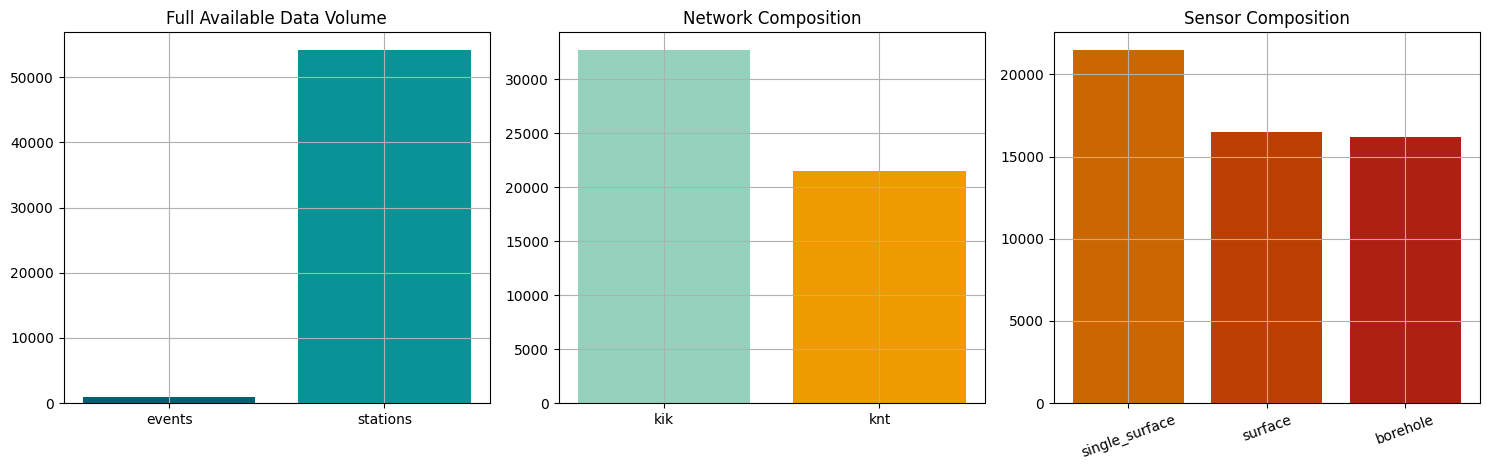

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

axes[0].bar(['events', 'stations'], [len(full_events), len(station_cache)], color=['#005f73', '#0a9396'])
axes[0].set_title('Full Available Data Volume')

network_counts = station_cache['source_network'].value_counts().sort_index()
axes[1].bar(network_counts.index, network_counts.values, color=['#94d2bd', '#ee9b00'])
axes[1].set_title('Network Composition')

sensor_counts = station_cache['sensor_class'].value_counts()
axes[2].bar(sensor_counts.index, sensor_counts.values, color=['#ca6702', '#bb3e03', '#ae2012'])
axes[2].set_title('Sensor Composition')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(OUT_DIR / 'full_dataset_scale.png', bbox_inches='tight')
plt.show()

## 3. Suggested Slide: Magnitude Coverage

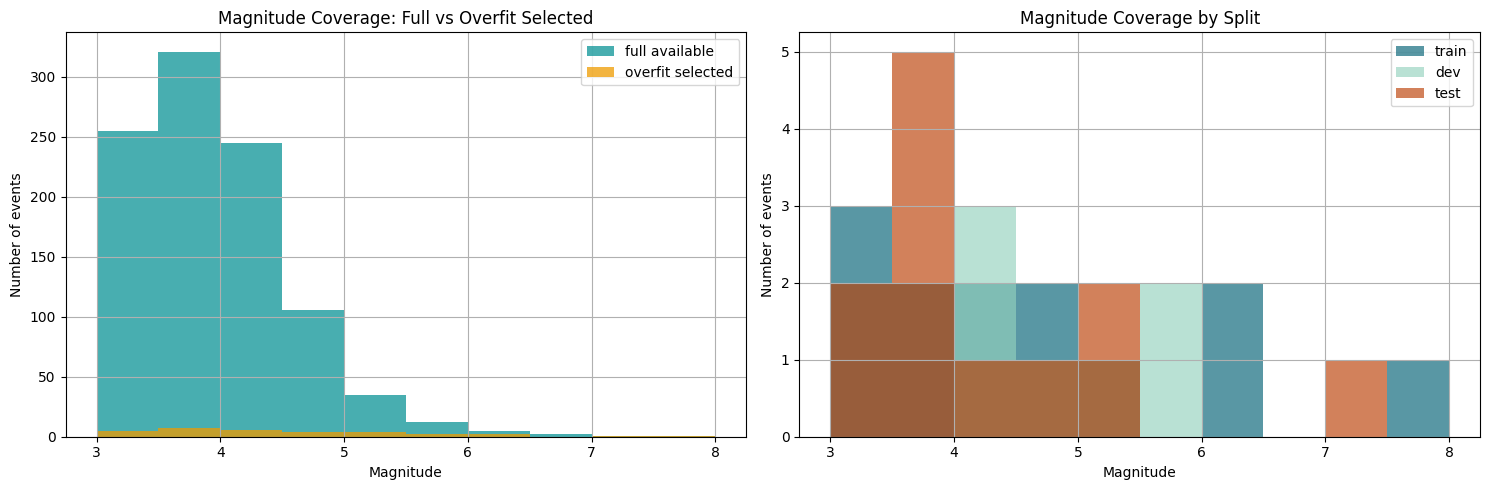

In [9]:
bins = np.arange(math.floor(full_events['Magnitude'].min() * 2) / 2, math.ceil(full_events['Magnitude'].max() * 2) / 2 + 0.5, 0.5)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(full_events['Magnitude'], bins=bins, alpha=0.75, color='#0a9396', label='full available')
axes[0].hist(overfit_events['Magnitude'], bins=bins, alpha=0.75, color='#ee9b00', label='overfit selected')
axes[0].set_title('Magnitude Coverage: Full vs Overfit Selected')
axes[0].set_xlabel('Magnitude')
axes[0].set_ylabel('Number of events')
axes[0].legend()

for split_name, df, color in [('train', train_events, '#005f73'), ('dev', dev_events, '#94d2bd'), ('test', test_events, '#bb3e03')]:
    axes[1].hist(df['Magnitude'], bins=bins, alpha=0.65, label=split_name, color=color)
axes[1].set_title('Magnitude Coverage by Split')
axes[1].set_xlabel('Magnitude')
axes[1].set_ylabel('Number of events')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'magnitude_coverage.png', bbox_inches='tight')
plt.show()
plt.close('all')

## 4. Suggested Slide: Geographic Coverage

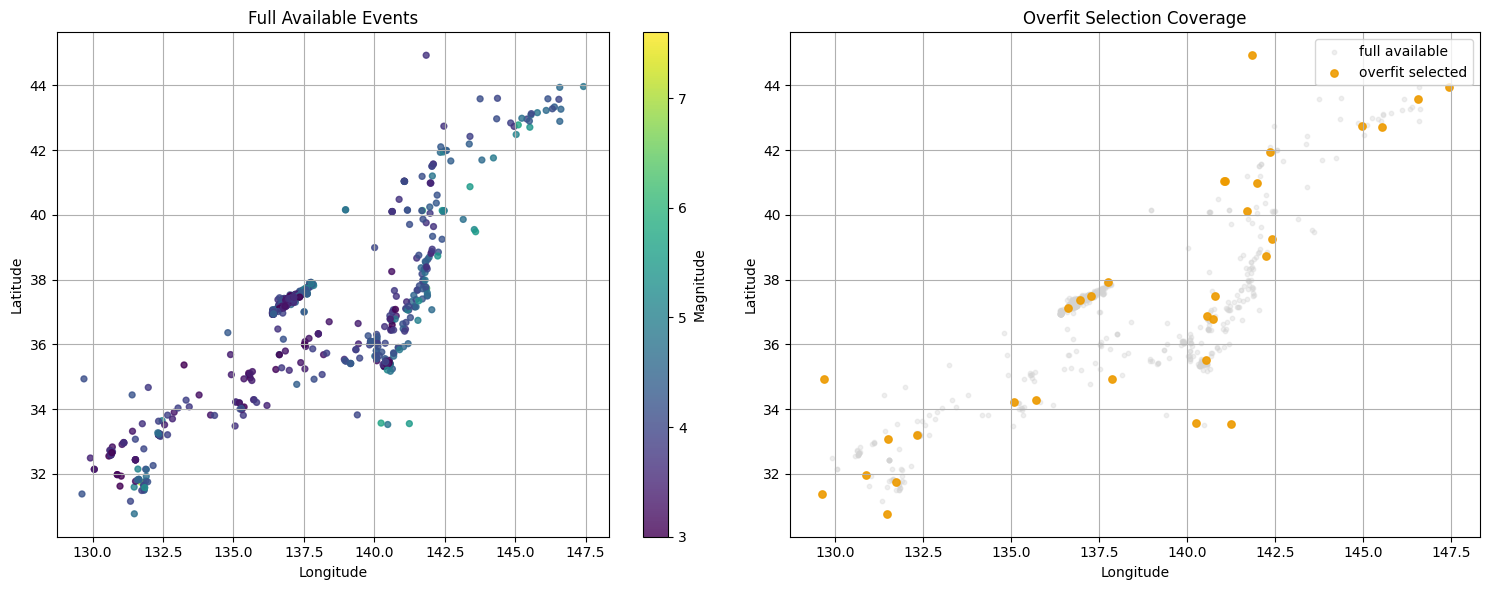

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc = axes[0].scatter(full_events['Longitude'], full_events['Latitude'], c=full_events['Magnitude'], s=18, cmap='viridis', alpha=0.8)
axes[0].set_title('Full Available Events')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
plt.colorbar(sc, ax=axes[0], label='Magnitude')

axes[1].scatter(full_events['Longitude'], full_events['Latitude'], s=10, color='lightgray', alpha=0.35, label='full available')
axes[1].scatter(overfit_events['Longitude'], overfit_events['Latitude'], s=28, color='#ee9b00', alpha=0.9, label='overfit selected')
axes[1].set_title('Overfit Selection Coverage')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'geographic_coverage.png', bbox_inches='tight')
plt.show()
plt.close('all')

## 5. Suggested Slide: Split And Overfit Distribution

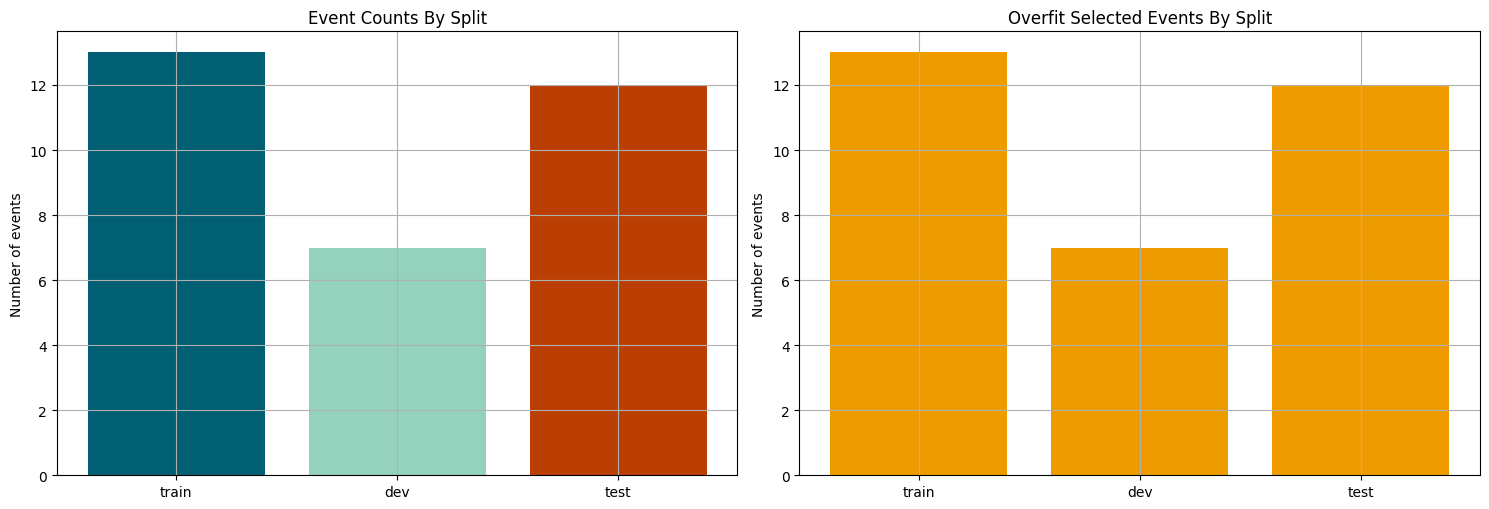

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

split_counts = split_events['split'].value_counts().reindex(['train', 'dev', 'test']).fillna(0)
axes[0].bar(split_counts.index, split_counts.values, color=['#005f73', '#94d2bd', '#bb3e03'])
axes[0].set_title('Event Counts By Split')
axes[0].set_ylabel('Number of events')

overfit_counts = split_events.groupby('split')['is_overfit_selected'].sum().reindex(['train', 'dev', 'test']).fillna(0)
axes[1].bar(overfit_counts.index, overfit_counts.values, color=['#ee9b00', '#ee9b00', '#ee9b00'])
axes[1].set_title('Overfit Selected Events By Split')
axes[1].set_ylabel('Number of events')

plt.tight_layout()
plt.savefig(OUT_DIR / 'split_and_overfit_distribution.png', bbox_inches='tight')
plt.show()
plt.close('all')

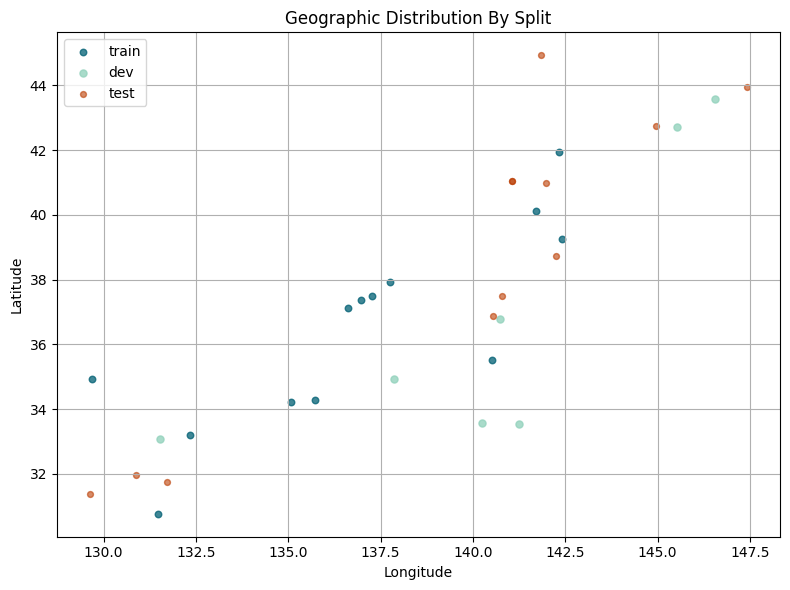

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(train_events['Longitude'], train_events['Latitude'], s=22, alpha=0.75, label='train', color='#005f73')
ax.scatter(dev_events['Longitude'], dev_events['Latitude'], s=26, alpha=0.8, label='dev', color='#94d2bd')
ax.scatter(test_events['Longitude'], test_events['Latitude'], s=18, alpha=0.6, label='test', color='#bb3e03')
ax.set_title('Geographic Distribution By Split')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'split_geographic_distribution.png', bbox_inches='tight')
plt.show()
plt.close('all')

## 6. Suggested Slide: Quality And Station Density

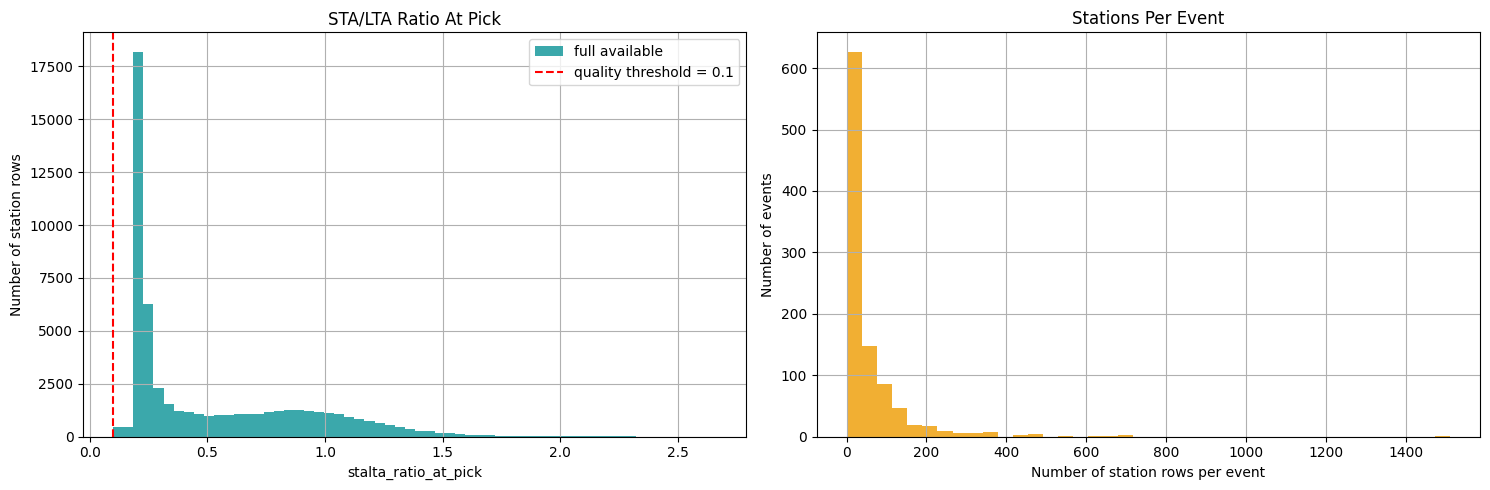

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(station_cache['stalta_ratio_at_pick'], bins=60, color='#0a9396', alpha=0.8, label='full available')
axes[0].axvline(0.1, color='red', linestyle='--', label='quality threshold = 0.1')
axes[0].set_title('STA/LTA Ratio At Pick')
axes[0].set_xlabel('stalta_ratio_at_pick')
axes[0].set_ylabel('Number of station rows')
axes[0].legend()

axes[1].hist(full_events['n_station_rows'], bins=40, color='#ee9b00', alpha=0.8)
axes[1].set_title('Stations Per Event')
axes[1].set_xlabel('Number of station rows per event')
axes[1].set_ylabel('Number of events')

plt.tight_layout()
plt.savefig(OUT_DIR / 'quality_and_station_density.png', bbox_inches='tight')
plt.show()
plt.close('all')

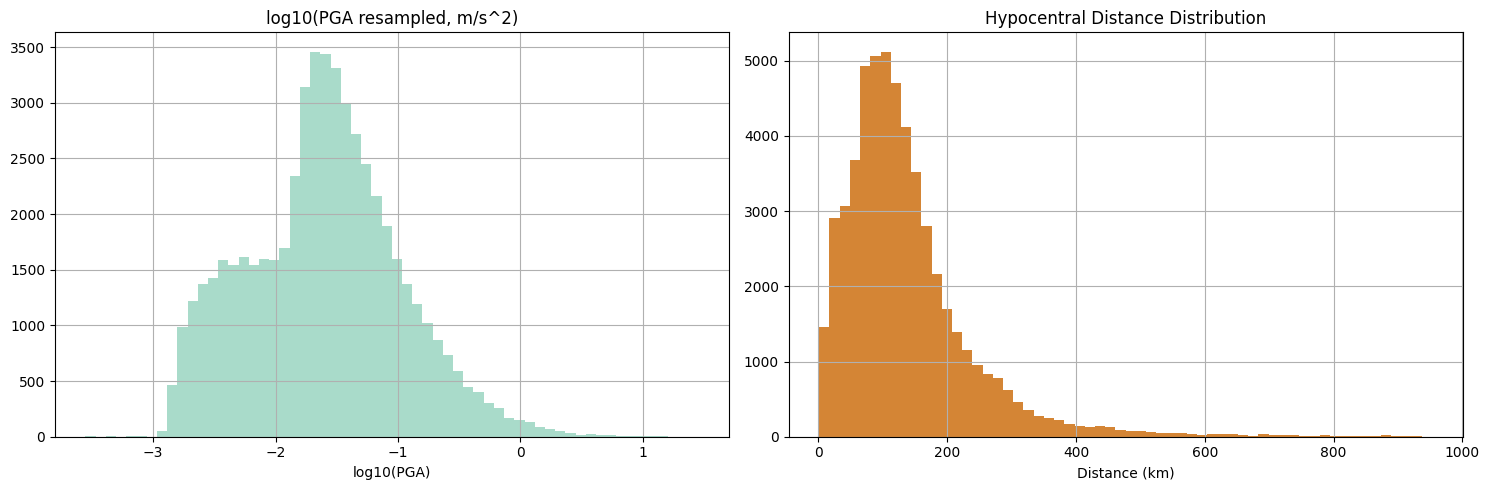

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(np.log10(np.maximum(station_cache['pga_norm_resampled_mps2'], 1e-12)), bins=60, color='#94d2bd', alpha=0.8)
axes[0].set_title('log10(PGA resampled, m/s^2)')
axes[0].set_xlabel('log10(PGA)')

axes[1].hist(station_cache['hypocentral_distance_km'], bins=60, color='#ca6702', alpha=0.8)
axes[1].set_title('Hypocentral Distance Distribution')
axes[1].set_xlabel('Distance (km)')

plt.tight_layout()
plt.savefig(OUT_DIR / 'pga_and_distance_distribution.png', bbox_inches='tight')
plt.show()
plt.close('all')

## 7. PPT Notes / Talking Points

In [15]:
notes = {
    'full_available_events': int(len(full_events)),
    'full_available_station_rows': int(len(station_cache)),
    'full_magnitude_range': [float(full_events['Magnitude'].min()), float(full_events['Magnitude'].max())],
    'full_network_counts': station_cache['source_network'].value_counts().to_dict(),
    'full_sensor_counts': station_cache['sensor_class'].value_counts().to_dict(),
    'split_event_counts': split_events['split'].value_counts().to_dict(),
    'split_station_counts': split_stations['split'].value_counts().to_dict(),
    'overfit_selected_event_count': int(len(overfit_events)),
    'overfit_selected_mag_range': [float(overfit_events['Magnitude'].min()), float(overfit_events['Magnitude'].max())],
    'overfit_events_by_split': split_events.groupby('split')['is_overfit_selected'].sum().to_dict(),
    'caveat': 'Current overfit implementation selects diverse events from the full set, then intersects them with train/dev/test splits. Therefore overfit-selected events are distributed across train/dev/test rather than forming a single train-only or train==dev subset.'
}

display(pd.DataFrame([notes]))
(OUT_DIR / 'ppt_notes.json').write_text(json.dumps(notes, indent=2, ensure_ascii=False))

,full_available_events,full_available_station_rows,full_magnitude_range,full_network_counts,full_sensor_counts,split_event_counts,split_station_counts,overfit_selected_event_count,overfit_selected_mag_range,overfit_events_by_split,caveat
0,983,54176,"[3.0, 7.6]","{'kik': 32691, 'knt': 21485}","{'single_surface': 21485, 'surface': 16518, 'b...","{'train': 13, 'test': 12, 'dev': 7}","{'train': 3044, 'test': 1239, 'dev': 1137}",32,"[3.0, 7.6]","{'dev': 7, 'test': 12, 'train': 13}",Current overfit implementation selects diverse...


905

In [16]:
print('Generated files:')
for path in sorted(OUT_DIR.iterdir()):
    print('-', path.name)

Generated files:
- dataset_summary.csv
- full_dataset_scale.png
- geographic_coverage.png
- magnitude_coverage.png
- overfit_split_event_counts.csv
- pga_and_distance_distribution.png
- ppt_notes.json
- quality_and_station_density.png
- split_and_overfit_distribution.png
- split_event_counts.csv
- split_geographic_distribution.png
- split_station_counts.csv
